In [1]:
import sys
sys.path.append('../bev')
from plan import Plan


In [2]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import SimpleITK as sitk
import numpy as np

def read_dose_parallel(file_paths, num_threads=32, scale_factor=1e5):
    n_files = len(file_paths)

    first_img = sitk.ReadImage(file_paths[0])
    spatial_shape = sitk.GetArrayFromImage(first_img).shape
    combined_array = np.zeros((n_files, *spatial_shape), dtype=np.float16)

    def load_and_insert(idx):
        file_path = file_paths[idx]
        image = sitk.ReadImage(file_path)
        # 2. Overwrite directly into the pre-allocated array
        combined_array[idx] = (sitk.GetArrayFromImage(image) * scale_factor).astype(np.float16)

    with ThreadPoolExecutor(max_workers=num_threads) as executor:
        list(tqdm(executor.map(load_and_insert, range(n_files)), total=n_files, desc="Reading files"))

    print(f"Starting parallel load with {num_threads} threads...")
    print(f"\nFinished. Final array shape: {combined_array.shape}")
    print(f"Data type: {combined_array.dtype}")

    return combined_array


In [3]:
from torch.utils.data import Dataset, DataLoader

class PlanData(Dataset):
    def __init__(self, plan):
        self.plan = plan
        self.n_beam = plan.n_beams
        self.ids = [(i, j) for i in range(self.plan.n_beams) for j in range(self.plan.beam_info[i]['n_cp'])]
        self.load_doses()

    def load_doses(self):
        self.doses = []
        for beam_idx in range(self.plan.n_beams):
            fl = [f'{self.plan.dose_dir}/Dose_B{beam_idx}_CP{i:03d}.mha' for i in range(self.plan.beam_info[beam_idx]['n_cp'])]
            self.doses.append(read_dose_parallel(fl, num_threads=32))
            break
        
    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        beam_id, cp_idx = self.ids[idx]
        
        return self.doses[beam_id][cp_idx]


In [4]:
plan = Plan(
    img_file_path=r"../data/DoseRAD2026/photon/training/1ABB006/image/ct.mha",
    info_json_path=r"../data/DoseRAD2026/photon/training/1ABB006/1ABB006.json",
    dose_dir=r"../data/DoseRAD2026/photon/training/1ABB006/dose",
)
print(plan.beam_info)

dataset = PlanData(plan)
    

OrderedDict([(0, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -28.13538836315937], 'n_mlc_leaf': 80, 'n_cp': 180}), (1, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -8.135388363159374], 'n_mlc_leaf': 80, 'n_cp': 180}), (2, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, 11.864611636840626], 'n_mlc_leaf': 80, 'n_cp': 180})])


Reading files:   0%|          | 0/180 [00:00<?, ?it/s]

Starting parallel load with 32 threads...

Finished. Final array shape: (180, 246, 246, 249)
Data type: float16


In [5]:
sys.path.append('../proton')
from proton_bev import rotate_image_batched
import torch

In [6]:
d = dataset.doses[0]
d = torch.tensor(d)


In [7]:
angles = torch.tensor([c['ga'] for c in plan.cp[0].values()]).cuda()

In [14]:
d[:10].shape

torch.Size([10, 246, 246, 249])

In [19]:
d_rotated = rotate_image_batched(
    d[:10].cuda(),  # Shape: (D, H, W) or (1, 1, D, H, W) on GPU
    dataset.plan.img.GetSpacing(),  # Can now be a torch.Tensor or list/tuple
    dataset.plan.img.GetOrigin(),  # Can now be a torch.Tensor or list/tuple
    dataset.plan.isocentre,  # Can now be a torch.Tensor or list/tuple
    angles[:10],  # Can now be a torch.Tensor of angles on GPU
    axis="z",
    bg_value=-1024,
    pad_voxels=None,
)

tensor([[[-1.0000e+00, -9.6750e-04,  0.0000e+00, -3.6206e-01],
         [ 9.6750e-04, -1.0000e+00,  0.0000e+00,  2.6782e-01],
         [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00]],

        [[-9.9951e-01, -3.4149e-02,  0.0000e+00, -3.5767e-01],
         [ 3.4149e-02, -9.9951e-01,  0.0000e+00,  2.7368e-01],
         [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00]],

        [[-9.9756e-01, -6.9275e-02,  0.0000e+00, -3.5278e-01],
         [ 6.9275e-02, -9.9756e-01,  0.0000e+00,  2.7979e-01],
         [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00]],

        [[-9.9463e-01, -1.0431e-01,  0.0000e+00, -3.4741e-01],
         [ 1.0431e-01, -9.9463e-01,  0.0000e+00,  2.8564e-01],
         [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00]],

        [[-9.9023e-01, -1.3916e-01,  0.0000e+00, -3.4204e-01],
         [ 1.3916e-01, -9.9023e-01,  0.0000e+00,  2.9150e-01],
         [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00]],

        [[-9.8486e-01, -1.7395e-01,  0.0000e+

[W815 03:37:24.019727716 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3015704576 bytes (free: 2093154304, total: 16721969152).


In [20]:
d_rotated = d_rotated.cpu()

In [11]:
import matplotlib.pyplot as plt

In [ ]:
d_rotated.shape

torch.Size([10, 10, 246, 246, 249])

: 

TypeError: Invalid shape (10, 246, 249) for image data

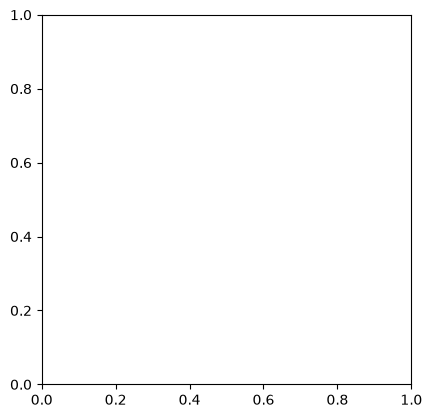

In [12]:
plt.imshow(d_rotated[0][:, 102])